In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
from datetime import datetime 

In [3]:
API_KEY = "GWN54BNLI0IX4E6G"

In [4]:
url = f"https://www.alphavantage.co/query?function=DIGITAL_CURRENCY_DAILY&symbol=BTC&market=USD&apikey={API_KEY}"
url

'https://www.alphavantage.co/query?function=DIGITAL_CURRENCY_DAILY&symbol=BTC&market=USD&apikey=GWN54BNLI0IX4E6G'

In [9]:
response = requests.get(url)

In [11]:
data = response.json()

In [13]:
data.keys()

dict_keys(['Meta Data', 'Time Series (Digital Currency Daily)'])

In [15]:
type(data['Meta Data'])

dict

In [16]:
data['Meta Data'].keys()

dict_keys(['1. Information', '2. Digital Currency Code', '3. Digital Currency Name', '4. Market Code', '5. Market Name', '6. Last Refreshed', '7. Time Zone'])

In [33]:
date_string = data['Meta Data']['6. Last Refreshed']
date_string
date_format = "%Y-%m-%d %H:%M:%S"

In [34]:
datetime.today()

datetime.datetime(2026, 6, 4, 14, 15, 9, 169114)

In [35]:
dt = datetime.strptime(date_string, date_format)

In [37]:
dt.year

2026

In [38]:
dt.day

4

In [44]:
d = data['Time Series (Digital Currency Daily)']
df =  pd.DataFrame().from_dict(d, orient="index")

In [51]:
df.columns = [i.split()[1].capitalize() for i in df.columns]

In [60]:
df = df.map(pd.to_numeric)

In [65]:
df.index = pd.to_datetime(df.index)

In [67]:
high_mask = df["Close"] == df["Close"].max()
low_mask = df["Close"] == df["Close"].min()
high = df[high_mask]
low = df[low_mask]
high

,Open,High,Low,Close,Volume
2025-10-06,123520.8,126296.0,123115.77,124720.09,9135.308645


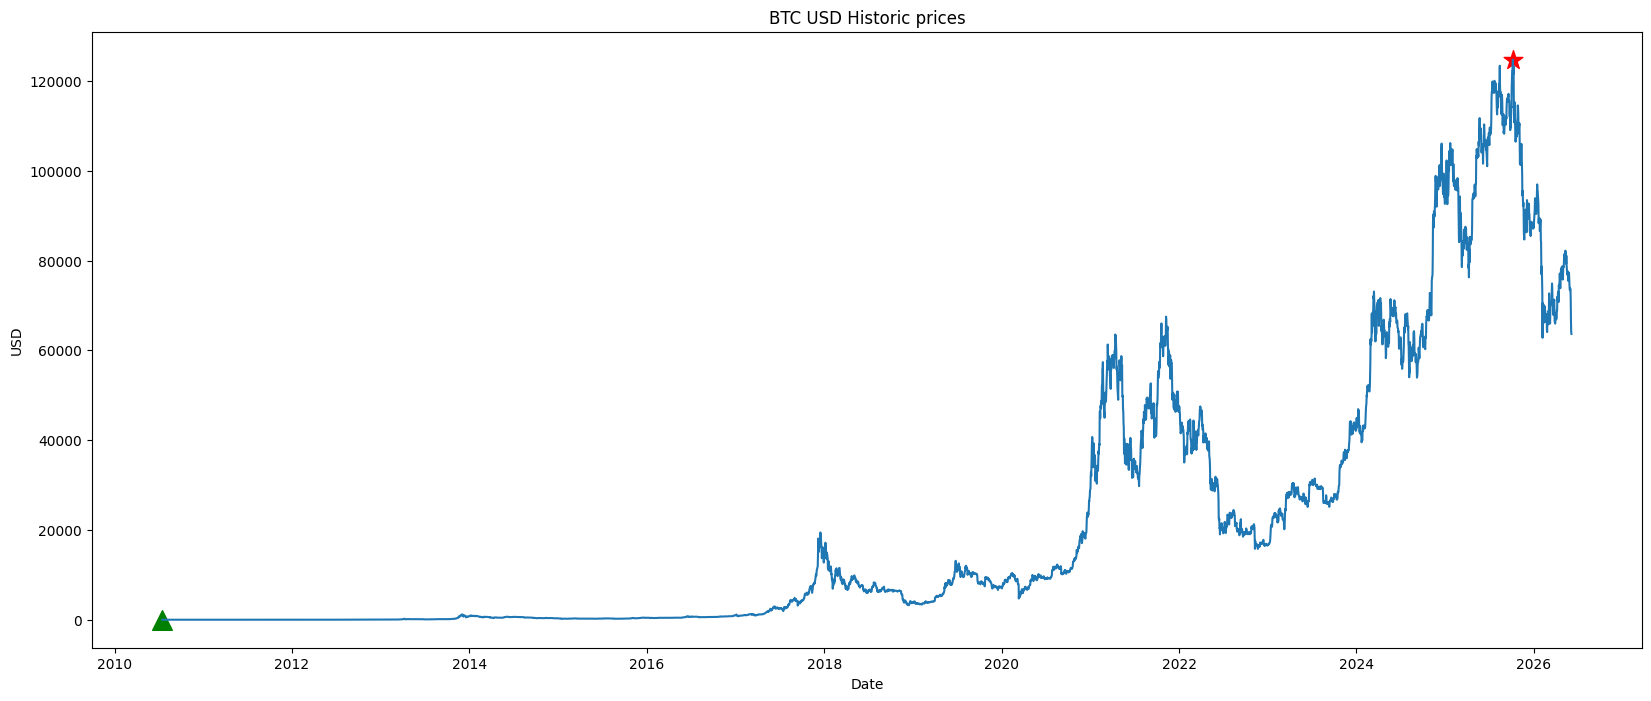

In [72]:
plt.figure(figsize=(20,8))
plt.plot(df.index, df["Close"])
plt.scatter(high.index, high["Close"], s=200, c="red",marker="*")
plt.scatter(low.index, low["Close"], s=200, c="green",marker="^")
plt.title("BTC USD Historic prices")
plt.ylabel("USD")
plt.xlabel("Date");